## Defualt params:
`(500, 500) and (1000, 1000) network area are *NOT* tested for node placement.`
1. Initial energy= 0.5J
2. Comm range= 50m
3. Sink speed= 25m/round
4. Net area= (100, 100)
5. Nodes num= 100

## Basic Methods

In [1]:
import sys
sys.path.append(r"D:\Papers\4) Finished Articles\6. MWSN - DCHPC\DCHPC\ModelClasses")
from simulation import Simulation
from ConfigClass.config import plot_comparison, visualize_deployment

In [2]:
def plot_time_series(time_series_dict, label, title, color='b'):

    rounds_list = time_series_dict['rounds']
    values_list = time_series_dict[label]

    max_len = max(len(r) for r in rounds_list)
    
    round_grid = np.full((len(rounds_list), max_len), np.nan)
    value_grid = np.full((len(values_list), max_len), np.nan)

    for i, (rds, vals) in enumerate(zip(rounds_list, values_list)):
        L = len(rds)
        round_grid[i, :L] = rds
        value_grid[i, :L] = vals

    avg_rounds = np.nanmean(round_grid, axis=0)  
    avg_vals = np.nanmean(value_grid, axis=0)
    std_vals = np.nanstd(value_grid, axis=0)


    valid = ~np.isnan(avg_vals)
    avg_rounds = avg_rounds[valid]
    avg_vals = avg_vals[valid]
    std_vals = std_vals[valid]

    plt.plot(avg_rounds, avg_vals, label=f'{title} (Mean)', color=color, linewidth=2)
    plt.fill_between(avg_rounds, 
                     avg_vals - std_vals, 
                     avg_vals + std_vals, 
                     color=color, alpha=0.2, label=f'{title} ± Std')

In [3]:
import numpy as np
import random


def run_multiple_simulations(area_size, n_nodes, sink_mode, routing_mode, mode, n_runs=30, CHS="optimizer", edge_threshold=0.4, tune_edge_iterations=20):
    FND, HND, LND, PDR = [], [], [], []
    TotalGenerated, TotalDelivered = [], []
    Avg_E2E_Delay_Rounds, Avg_E2E_Delay_Sec = [], []
    ca_runs, lb_runs, ec_runs, round_runs = [], [], [], []
    for seed in range(n_runs):
        np.random.seed(seed)
        random.seed(seed)
        sim = Simulation(
            area_size=area_size,
            n_nodes=n_nodes,
            rounds=60000,
            init_energy=0.5,
            comm_range=50.0,
            sink_mode=sink_mode,
            routing_mode=routing_mode,
            seed=seed,
            localization_mode=mode,
            head_selection_strategy=CHS,
            edge_threshold=edge_threshold,
            tune_edge_iterations=tune_edge_iterations
        )
        metrics, detailed_metrics = sim.run()

        rounds = np.array(detailed_metrics['round'])
        ca_vals = np.array(detailed_metrics['CA'])
        lb_vals = np.array(detailed_metrics['LB'])
        ec_vals = np.array(detailed_metrics['EC'])

        round_runs.append(rounds)
        ca_runs.append(ca_vals)
        lb_runs.append(lb_vals)
        ec_runs.append(ec_vals)

        plot_res = {
            'rounds': round_runs,
            'CA': ca_runs,
            'LB': lb_runs,
            'EC': ec_runs
        }

        FND.append(metrics['FND'])
        HND.append(metrics['HND'])
        LND.append(metrics['LND'])
        PDR.append(metrics['PDR'])
        TotalGenerated.append(metrics['TotalGenerated'])
        TotalDelivered.append(metrics['TotalDelivered'])
        Avg_E2E_Delay_Rounds.append(metrics['Avg_E2E_Delay_Rounds'])
        Avg_E2E_Delay_Sec.append(metrics['Avg_E2E_Delay_Sec'])
    print("\n")

    return [np.array(FND), np.array(HND), np.array(LND),
            np.array(PDR), np.array(TotalGenerated), np.array(TotalDelivered),
            np.array(Avg_E2E_Delay_Rounds), np.array(Avg_E2E_Delay_Sec)], plot_res

## Random Node Deployment vs. Voronoi-RL 

### (100, 100) area size, 100 nodes

In [4]:
# Run both methods
drl_lifetimes, plot_drl = run_multiple_simulations(area_size=(
    100, 100), n_nodes=100, sink_mode="eeosp", routing_mode="multi-hop", mode="DRL", n_runs=30)
baseline_lifetimes, plot_base = run_multiple_simulations(area_size=(
    100, 100), n_nodes=100, sink_mode="eeosp", routing_mode="multi-hop", mode="random", n_runs=30)


print(
    f"Mean DRL FND: {drl_lifetimes[0].mean():.2f} ± {drl_lifetimes[0].std():.2f}")
print(
    f"Mean DRL HND: {drl_lifetimes[1].mean():.2f} ± {drl_lifetimes[1].std():.2f}")
print(
    f"Mean DRL LND: {drl_lifetimes[2].mean():.2f} ± {drl_lifetimes[2].std():.2f}")
print(
    f"Mean DRL PDR: {drl_lifetimes[3].mean():.2f} ± {drl_lifetimes[3].std():.2f}")
print(
    f"Mean DRL TotalGenerated: {drl_lifetimes[4].mean():.2f} ± {drl_lifetimes[4].std():.2f}")
print(
    f"Mean DRL TotalDelivered: {drl_lifetimes[5].mean():.2f} ± {drl_lifetimes[5].std():.2f}")
print(
    f"Mean DRL Avg_E2E_Delay_Rounds: {drl_lifetimes[6].mean():.2f} ± {drl_lifetimes[6].std():.2f}")
print(
    f"Mean DRL Avg_E2E_Delay_Sec: {drl_lifetimes[7].mean():.2f} ± {drl_lifetimes[7].std():.2f}")


print("\n\n\n")
print(
    f"Mean Baseline FND: {baseline_lifetimes[0].mean():.2f} ± {baseline_lifetimes[0].std():.2f}")
print(
    f"Mean Baseline HND: {baseline_lifetimes[1].mean():.2f} ± {baseline_lifetimes[1].std():.2f}")
print(
    f"Mean Baseline LND: {baseline_lifetimes[2].mean():.2f} ± {baseline_lifetimes[2].std():.2f}")
print(
    f"Mean Baseline PDR: {baseline_lifetimes[3].mean():.2f} ± {baseline_lifetimes[3].std():.2f}")
print(
    f"Mean Baseline TotalGenerated: {baseline_lifetimes[4].mean():.2f} ± {baseline_lifetimes[4].std():.2f}")
print(
    f"Mean Baseline TotalDelivered: {baseline_lifetimes[5].mean():.2f} ± {baseline_lifetimes[5].std():.2f}")
print(
    f"Mean Baseline Avg_E2E_Delay_Rounds: {baseline_lifetimes[6].mean():.2f} ± {baseline_lifetimes[6].std():.2f}")
print(
    f"Mean Baseline Avg_E2E_Delay_Sec: {baseline_lifetimes[7].mean():.2f} ± {baseline_lifetimes[7].std():.2f}")

[3, 4, 7, 8, 9, 10, 13, 17, 19, 23, 26, 27, 30, 33, 34, 37, 38, 41, 44, 46, 48, 49, 51, 54, 59, 61, 63, 66, 71, 73, 74, 75, 77, 79, 82, 83, 85, 86, 88, 89, 96]
[DRL] Fine-tuning 41 edge nodes...
  Iteration 0: 8/41 nodes improved, Global Reward: 0.9519
  Iteration 10: 10/41 nodes improved, Global Reward: 0.9520
[DRL] Optimization complete. Final reward: 0.9520, 35 nodes changed position.
[Info] Sink speed: 25.0 m/round = 0.50 m/s
[1, 2, 6, 10, 12, 13, 14, 16, 19, 20, 23, 25, 27, 28, 34, 35, 38, 43, 45, 48, 51, 52, 53, 54, 55, 56, 58, 59, 60, 61, 65, 66, 67, 69, 70, 71, 72, 74, 75, 79, 82, 85, 91, 95, 97, 98]
[DRL] Fine-tuning 46 edge nodes...
  Iteration 0: 6/46 nodes improved, Global Reward: 0.9523
  Iteration 10: 7/46 nodes improved, Global Reward: 0.9523
[DRL] Optimization complete. Final reward: 0.9523, 37 nodes changed position.
[Info] Sink speed: 25.0 m/round = 0.50 m/s
[7, 9, 12, 19, 20, 21, 24, 29, 34, 37, 44, 45, 49, 51, 53, 55, 63, 68, 69, 71, 73, 75, 77, 78, 82, 86, 89, 91, 

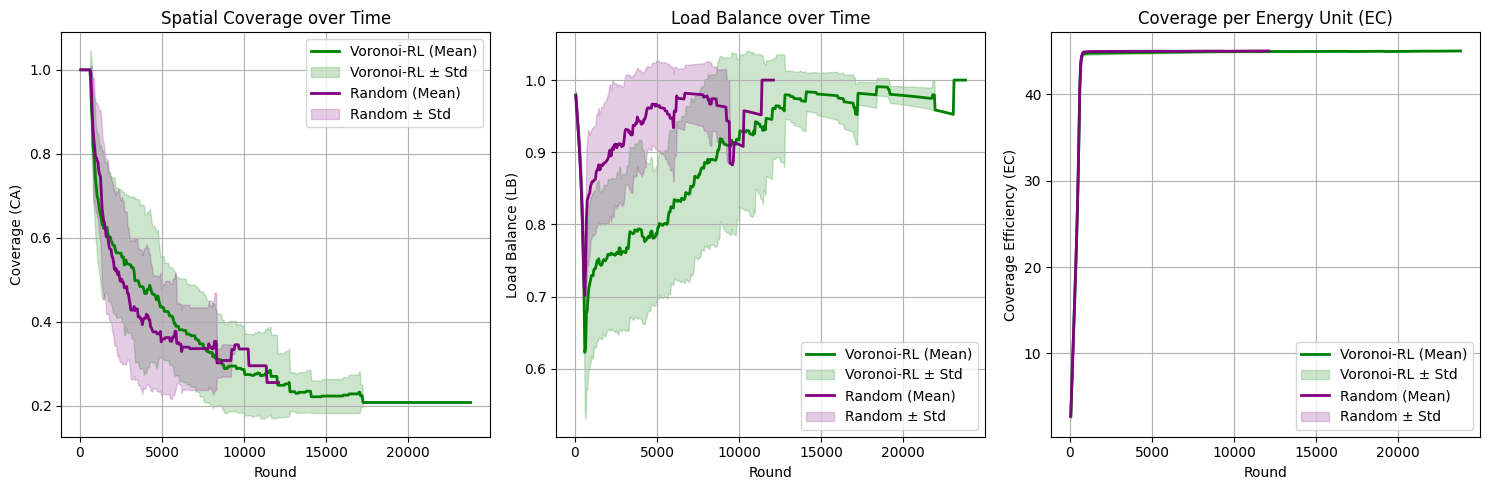

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))

# CA
plt.subplot(1, 3, 1)
plot_time_series(plot_drl, 'CA', "Voronoi-RL", color='green')
plot_time_series(plot_base, 'CA', "Random", color='purple')
plt.xlabel('Round')
plt.ylabel('Coverage (CA)')
plt.title('Spatial Coverage over Time')
plt.grid(True)
plt.legend()

# LB
plt.subplot(1, 3, 2)
plot_time_series(plot_drl, 'LB', "Voronoi-RL", color='green')
plot_time_series(plot_base, 'LB', "Random", color='purple')
plt.xlabel('Round')
plt.ylabel('Load Balance (LB)')
plt.title('Load Balance over Time')
plt.grid(True)
plt.legend()

# CE
plt.subplot(1, 3, 3)
plot_time_series(plot_drl, 'EC', "Voronoi-RL", color='green')
plot_time_series(plot_base, 'EC', "Random", color='purple')
plt.xlabel('Round')
plt.ylabel('Coverage Efficiency (EC)')
plt.title('Coverage per Energy Unit (EC)')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.savefig('metrics_over_time.png', dpi=300, bbox_inches='tight')
plt.show()

### (200, 200) area size, 100 nodes

In [6]:
# Run both methods
drl_lifetimes, plot_drl = run_multiple_simulations(area_size=(
    200, 200), n_nodes=100, sink_mode="eeosp", routing_mode="multi-hop", mode="DRL", n_runs=30)
baseline_lifetimes, plot_base = run_multiple_simulations(area_size=(
    200, 200), n_nodes=100, sink_mode="eeosp", routing_mode="multi-hop", mode="random", n_runs=30)


print(
    f"Mean DRL FND: {drl_lifetimes[0].mean():.2f} ± {drl_lifetimes[0].std():.2f}")
print(
    f"Mean DRL HND: {drl_lifetimes[1].mean():.2f} ± {drl_lifetimes[1].std():.2f}")
print(
    f"Mean DRL LND: {drl_lifetimes[2].mean():.2f} ± {drl_lifetimes[2].std():.2f}")
print(
    f"Mean DRL PDR: {drl_lifetimes[3].mean():.2f} ± {drl_lifetimes[3].std():.2f}")
print(
    f"Mean DRL TotalGenerated: {drl_lifetimes[4].mean():.2f} ± {drl_lifetimes[4].std():.2f}")
print(
    f"Mean DRL TotalDelivered: {drl_lifetimes[5].mean():.2f} ± {drl_lifetimes[5].std():.2f}")
print(
    f"Mean DRL Avg_E2E_Delay_Rounds: {drl_lifetimes[6].mean():.2f} ± {drl_lifetimes[6].std():.2f}")
print(
    f"Mean DRL Avg_E2E_Delay_Sec: {drl_lifetimes[7].mean():.2f} ± {drl_lifetimes[7].std():.2f}")


print("\n\n\n")
print(
    f"Mean Baseline FND: {baseline_lifetimes[0].mean():.2f} ± {baseline_lifetimes[0].std():.2f}")
print(
    f"Mean Baseline HND: {baseline_lifetimes[1].mean():.2f} ± {baseline_lifetimes[1].std():.2f}")
print(
    f"Mean Baseline LND: {baseline_lifetimes[2].mean():.2f} ± {baseline_lifetimes[2].std():.2f}")
print(
    f"Mean Baseline PDR: {baseline_lifetimes[3].mean():.2f} ± {baseline_lifetimes[3].std():.2f}")
print(
    f"Mean Baseline TotalGenerated: {baseline_lifetimes[4].mean():.2f} ± {baseline_lifetimes[4].std():.2f}")
print(
    f"Mean Baseline TotalDelivered: {baseline_lifetimes[5].mean():.2f} ± {baseline_lifetimes[5].std():.2f}")
print(
    f"Mean Baseline Avg_E2E_Delay_Rounds: {baseline_lifetimes[6].mean():.2f} ± {baseline_lifetimes[6].std():.2f}")
print(
    f"Mean Baseline Avg_E2E_Delay_Sec: {baseline_lifetimes[7].mean():.2f} ± {baseline_lifetimes[7].std():.2f}")

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99]
[DRL] Fine-tuning 100 edge nodes...
  Iteration 0: 45/100 nodes improved, Global Reward: 0.9524
  Iteration 10: 20/100 nodes improved, Global Reward: 0.9522
[DRL] Optimization complete. Final reward: 0.9313, 97 nodes changed position.
[Info] Sink speed: 25.0 m/round = 0.50 m/s
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 

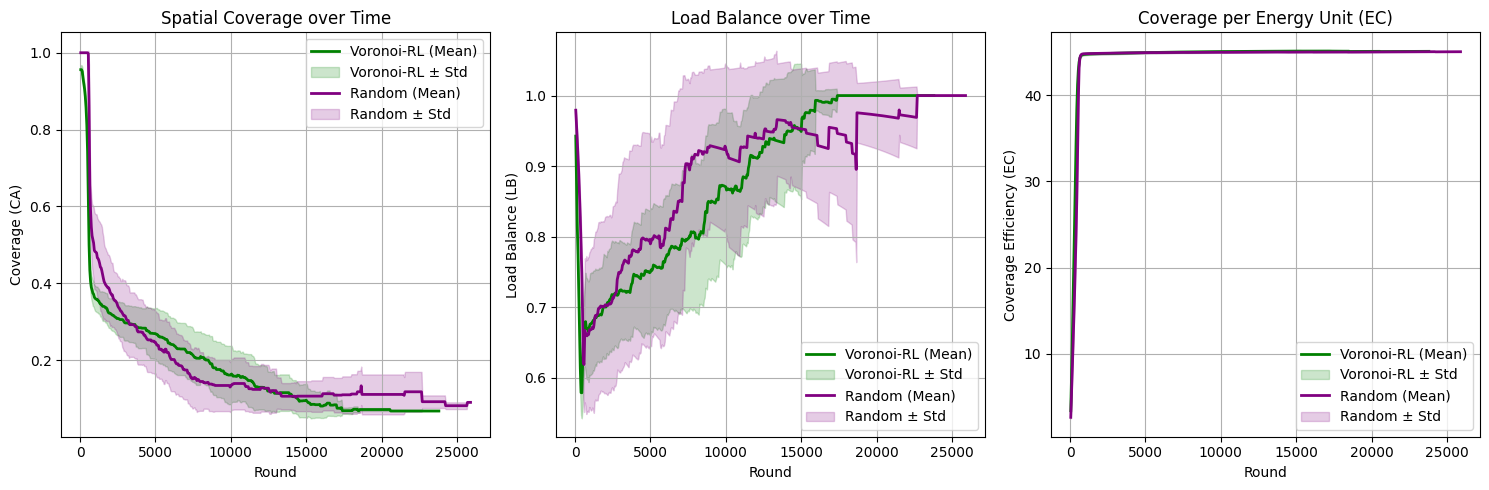

In [8]:
plt.figure(figsize=(15, 5))

# CA
plt.subplot(1, 3, 1)
plot_time_series(plot_drl, 'CA', "Voronoi-RL", color='green')
plot_time_series(plot_base, 'CA', "Random", color='purple')
plt.xlabel('Round')
plt.ylabel('Coverage (CA)')
plt.title('Spatial Coverage over Time')
plt.grid(True)
plt.legend()

# LB
plt.subplot(1, 3, 2)
plot_time_series(plot_drl, 'LB', "Voronoi-RL", color='green')
plot_time_series(plot_base, 'LB', "Random", color='purple')
plt.xlabel('Round')
plt.ylabel('Load Balance (LB)')
plt.title('Load Balance over Time')
plt.grid(True)
plt.legend()

# CE
plt.subplot(1, 3, 3)
plot_time_series(plot_drl, 'EC', "Voronoi-RL", color='green')
plot_time_series(plot_base, 'EC', "Random", color='purple')
plt.xlabel('Round')
plt.ylabel('Coverage Efficiency (EC)')
plt.title('Coverage per Energy Unit (EC)')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.savefig('metrics_over_time.png', dpi=300, bbox_inches='tight')
plt.show()

### (500, 500) area size, 100 nodes

In [ ]:
# Run both methods
drl_lifetimes, plot_drl = run_multiple_simulations(area_size=(
    500, 500), n_nodes=100, sink_mode="eeosp", routing_mode="multi-hop", mode="DRL", n_runs=30, edge_threshold=0.01, tune_edge_iterations=10)
baseline_lifetimes, plot_base = run_multiple_simulations(area_size=(
    500, 500), n_nodes=100, sink_mode="eeosp", routing_mode="multi-hop", mode="random", n_runs=30)


print(
    f"Mean DRL FND: {drl_lifetimes[0].mean():.2f} ± {drl_lifetimes[0].std():.2f}")
print(
    f"Mean DRL HND: {drl_lifetimes[1].mean():.2f} ± {drl_lifetimes[1].std():.2f}")
print(
    f"Mean DRL LND: {drl_lifetimes[2].mean():.2f} ± {drl_lifetimes[2].std():.2f}")
print(
    f"Mean DRL PDR: {drl_lifetimes[3].mean():.2f} ± {drl_lifetimes[3].std():.2f}")
print(
    f"Mean DRL TotalGenerated: {drl_lifetimes[4].mean():.2f} ± {drl_lifetimes[4].std():.2f}")
print(
    f"Mean DRL TotalDelivered: {drl_lifetimes[5].mean():.2f} ± {drl_lifetimes[5].std():.2f}")
print(
    f"Mean DRL Avg_E2E_Delay_Rounds: {drl_lifetimes[6].mean():.2f} ± {drl_lifetimes[6].std():.2f}")
print(
    f"Mean DRL Avg_E2E_Delay_Sec: {drl_lifetimes[7].mean():.2f} ± {drl_lifetimes[7].std():.2f}")


print("\n\n\n")
print(
    f"Mean Baseline FND: {baseline_lifetimes[0].mean():.2f} ± {baseline_lifetimes[0].std():.2f}")
print(
    f"Mean Baseline HND: {baseline_lifetimes[1].mean():.2f} ± {baseline_lifetimes[1].std():.2f}")
print(
    f"Mean Baseline LND: {baseline_lifetimes[2].mean():.2f} ± {baseline_lifetimes[2].std():.2f}")
print(
    f"Mean Baseline PDR: {baseline_lifetimes[3].mean():.2f} ± {baseline_lifetimes[3].std():.2f}")
print(
    f"Mean Baseline TotalGenerated: {baseline_lifetimes[4].mean():.2f} ± {baseline_lifetimes[4].std():.2f}")
print(
    f"Mean Baseline TotalDelivered: {baseline_lifetimes[5].mean():.2f} ± {baseline_lifetimes[5].std():.2f}")
print(
    f"Mean Baseline Avg_E2E_Delay_Rounds: {baseline_lifetimes[6].mean():.2f} ± {baseline_lifetimes[6].std():.2f}")
print(
    f"Mean Baseline Avg_E2E_Delay_Sec: {baseline_lifetimes[7].mean():.2f} ± {baseline_lifetimes[7].std():.2f}")

[0, 3, 4, 6, 7, 8, 9, 10, 12, 14, 15, 17, 22, 24, 26, 27, 35, 41, 43, 44, 45, 48, 49, 51, 52, 54, 57, 60, 63, 66, 70, 74, 75, 76, 78, 81, 82, 83, 85, 90, 98, 99]
[DRL] Fine-tuning 42 edge nodes...
  Iteration 0: 32/42 nodes improved, Global Reward: 0.7475
[DRL] Optimization complete. Final reward: 0.7006, 42 nodes changed position.
[Info] Sink speed: 25.0 m/round = 0.50 m/s
[3, 4, 5, 8, 10, 11, 12, 14, 16, 19, 20, 23, 25, 26, 27, 29, 35, 36, 38, 39, 41, 42, 43, 44, 45, 47, 51, 55, 57, 59, 62, 66, 67, 68, 74, 76, 82, 85, 86, 87, 91, 95]
[DRL] Fine-tuning 42 edge nodes...
  Iteration 0: 36/42 nodes improved, Global Reward: 0.7470
[DRL] Optimization complete. Final reward: 0.7121, 42 nodes changed position.
[Info] Sink speed: 25.0 m/round = 0.50 m/s
[3, 6, 7, 8, 12, 15, 19, 21, 23, 24, 26, 29, 31, 34, 37, 39, 40, 44, 47, 48, 49, 51, 53, 55, 57, 60, 63, 68, 71, 74, 75, 77, 78, 80, 82, 86, 89, 92, 94, 99]
[DRL] Fine-tuning 40 edge nodes...
  Iteration 0: 30/40 nodes improved, Global Reward:

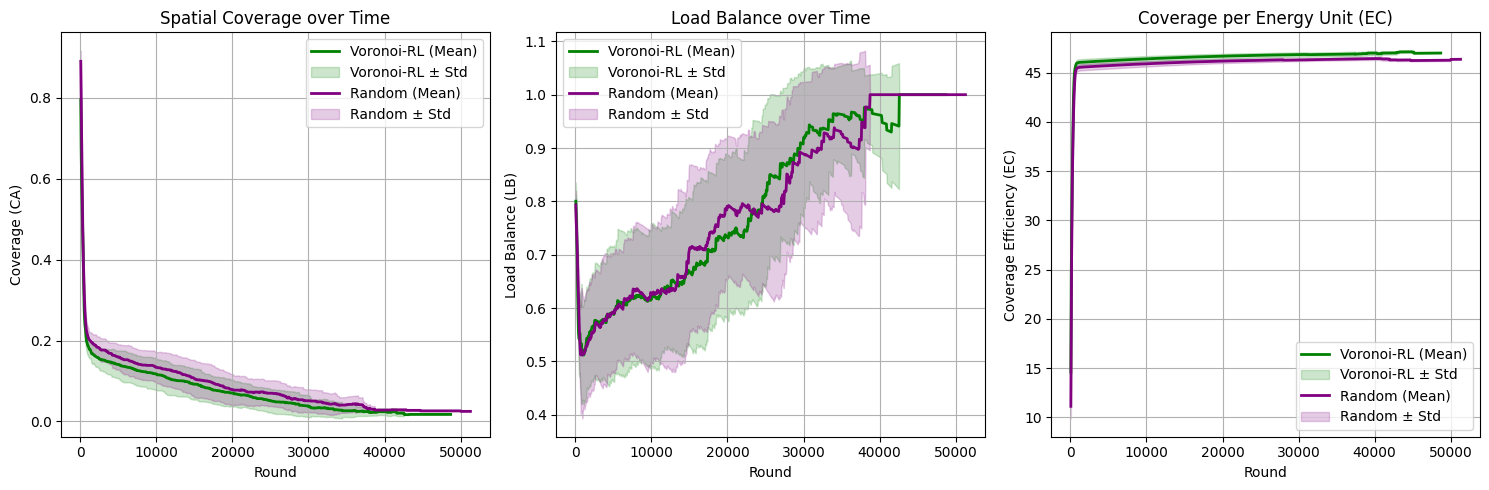

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))

# CA
plt.subplot(1, 3, 1)
plot_time_series(plot_drl, 'CA', "Voronoi-RL", color='green')
plot_time_series(plot_base, 'CA', "Random", color='purple')
plt.xlabel('Round')
plt.ylabel('Coverage (CA)')
plt.title('Spatial Coverage over Time')
plt.grid(True)
plt.legend()

# LB
plt.subplot(1, 3, 2)
plot_time_series(plot_drl, 'LB', "Voronoi-RL", color='green')
plot_time_series(plot_base, 'LB', "Random", color='purple')
plt.xlabel('Round')
plt.ylabel('Load Balance (LB)')
plt.title('Load Balance over Time')
plt.grid(True)
plt.legend()

# CE
plt.subplot(1, 3, 3)
plot_time_series(plot_drl, 'EC', "Voronoi-RL", color='green')
plot_time_series(plot_base, 'EC', "Random", color='purple')
plt.xlabel('Round')
plt.ylabel('Coverage Efficiency (EC)')
plt.title('Coverage per Energy Unit (EC)')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.savefig('metrics_over_time.png', dpi=300, bbox_inches='tight')
plt.show()

### (1000, 1000) area size, 100 nodes

In [ ]:
# Run both methods
drl_lifetimes, plot_drl = run_multiple_simulations(area_size=(
    1000, 1000), n_nodes=100, sink_mode="eeosp", routing_mode="multi-hop", mode="DRL", n_runs=30, edge_threshold=0.01, tune_edge_iterations=10)
baseline_lifetimes, plot_base = run_multiple_simulations(area_size=(
    1000, 1000), n_nodes=100, sink_mode="eeosp", routing_mode="multi-hop", mode="random", n_runs=30)


print(
    f"Mean DRL FND: {drl_lifetimes[0].mean():.2f} ± {drl_lifetimes[0].std():.2f}")
print(
    f"Mean DRL HND: {drl_lifetimes[1].mean():.2f} ± {drl_lifetimes[1].std():.2f}")
print(
    f"Mean DRL LND: {drl_lifetimes[2].mean():.2f} ± {drl_lifetimes[2].std():.2f}")
print(
    f"Mean DRL PDR: {drl_lifetimes[3].mean():.2f} ± {drl_lifetimes[3].std():.2f}")
print(
    f"Mean DRL TotalGenerated: {drl_lifetimes[4].mean():.2f} ± {drl_lifetimes[4].std():.2f}")
print(
    f"Mean DRL TotalDelivered: {drl_lifetimes[5].mean():.2f} ± {drl_lifetimes[5].std():.2f}")
print(
    f"Mean DRL Avg_E2E_Delay_Rounds: {drl_lifetimes[6].mean():.2f} ± {drl_lifetimes[6].std():.2f}")
print(
    f"Mean DRL Avg_E2E_Delay_Sec: {drl_lifetimes[7].mean():.2f} ± {drl_lifetimes[7].std():.2f}")


print("\n\n\n")
print(
    f"Mean Baseline FND: {baseline_lifetimes[0].mean():.2f} ± {baseline_lifetimes[0].std():.2f}")
print(
    f"Mean Baseline HND: {baseline_lifetimes[1].mean():.2f} ± {baseline_lifetimes[1].std():.2f}")
print(
    f"Mean Baseline LND: {baseline_lifetimes[2].mean():.2f} ± {baseline_lifetimes[2].std():.2f}")
print(
    f"Mean Baseline PDR: {baseline_lifetimes[3].mean():.2f} ± {baseline_lifetimes[3].std():.2f}")
print(
    f"Mean Baseline TotalGenerated: {baseline_lifetimes[4].mean():.2f} ± {baseline_lifetimes[4].std():.2f}")
print(
    f"Mean Baseline TotalDelivered: {baseline_lifetimes[5].mean():.2f} ± {baseline_lifetimes[5].std():.2f}")
print(
    f"Mean Baseline Avg_E2E_Delay_Rounds: {baseline_lifetimes[6].mean():.2f} ± {baseline_lifetimes[6].std():.2f}")
print(
    f"Mean Baseline Avg_E2E_Delay_Sec: {baseline_lifetimes[7].mean():.2f} ± {baseline_lifetimes[7].std():.2f}")

In [ ]:
plt.figure(figsize=(15, 5))

# CA
plt.subplot(1, 3, 1)
plot_time_series(plot_drl, 'CA', "Voronoi-RL", color='green')
plot_time_series(plot_base, 'CA', "Random", color='purple')
plt.xlabel('Round')
plt.ylabel('Coverage (CA)')
plt.title('Spatial Coverage over Time')
plt.grid(True)
plt.legend()

# LB
plt.subplot(1, 3, 2)
plot_time_series(plot_drl, 'LB', "Voronoi-RL", color='green')
plot_time_series(plot_base, 'LB', "Random", color='purple')
plt.xlabel('Round')
plt.ylabel('Load Balance (LB)')
plt.title('Load Balance over Time')
plt.grid(True)
plt.legend()

# CE
plt.subplot(1, 3, 3)
plot_time_series(plot_drl, 'EC', "Voronoi-RL", color='green')
plot_time_series(plot_base, 'EC', "Random", color='purple')
plt.xlabel('Round')
plt.ylabel('Coverage Efficiency (EC)')
plt.title('Coverage per Energy Unit (EC)')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.savefig('metrics_over_time.png', dpi=300, bbox_inches='tight')
plt.show()

## Different MS patterns

In [9]:
# Run both methods
eeosp_lifetimes, plot_eeosp = run_multiple_simulations(area_size=(
    100, 100), n_nodes=100, sink_mode="eeosp", routing_mode="multi-hop", mode="random", n_runs=30)
adaptive_lifetimes, plot_adaptive = run_multiple_simulations(area_size=(
    100, 100), n_nodes=100, sink_mode="adaptive", routing_mode="multi-hop", mode="random", n_runs=30)
fixed_lifetimes, plot_fixed = run_multiple_simulations(area_size=(
    100, 100), n_nodes=100, sink_mode="fixed", routing_mode="multi-hop", mode="random", n_runs=30)
random_lifetimes, plot_random = run_multiple_simulations(area_size=(
    100, 100), n_nodes=100, sink_mode="random", routing_mode="multi-hop", mode="random", n_runs=30)

print(
    f"Mean eeosp FND: {eeosp_lifetimes[0].mean():.2f} ± {eeosp_lifetimes[0].std():.2f}")
print(
    f"Mean eeosp HND: {eeosp_lifetimes[1].mean():.2f} ± {eeosp_lifetimes[1].std():.2f}")
print(
    f"Mean eeosp LND: {eeosp_lifetimes[2].mean():.2f} ± {eeosp_lifetimes[2].std():.2f}")
print(
    f"Mean eeosp PDR: {eeosp_lifetimes[3].mean():.2f} ± {eeosp_lifetimes[3].std():.2f}")
print(
    f"Mean eeosp TotalGenerated: {eeosp_lifetimes[4].mean():.2f} ± {eeosp_lifetimes[4].std():.2f}")
print(
    f"Mean eeosp TotalDelivered: {eeosp_lifetimes[5].mean():.2f} ± {eeosp_lifetimes[5].std():.2f}")
print(
    f"Mean eeosp Avg_E2E_Delay_Rounds: {eeosp_lifetimes[6].mean():.2f} ± {eeosp_lifetimes[6].std():.2f}")
print(
    f"Mean eeosp Avg_E2E_Delay_Sec: {eeosp_lifetimes[7].mean():.2f} ± {eeosp_lifetimes[7].std():.2f}")


print("\n\n")
print(
    f"Mean adaptive FND: {adaptive_lifetimes[0].mean():.2f} ± {adaptive_lifetimes[0].std():.2f}")
print(
    f"Mean adaptive HND: {adaptive_lifetimes[1].mean():.2f} ± {adaptive_lifetimes[1].std():.2f}")
print(
    f"Mean adaptive LND: {adaptive_lifetimes[2].mean():.2f} ± {adaptive_lifetimes[2].std():.2f}")
print(
    f"Mean adaptive PDR: {adaptive_lifetimes[3].mean():.2f} ± {adaptive_lifetimes[3].std():.2f}")
print(
    f"Mean adaptive TotalGenerated: {adaptive_lifetimes[4].mean():.2f} ± {adaptive_lifetimes[4].std():.2f}")
print(
    f"Mean adaptive TotalDelivered: {adaptive_lifetimes[5].mean():.2f} ± {adaptive_lifetimes[5].std():.2f}")
print(
    f"Mean adaptive Avg_E2E_Delay_Rounds: {adaptive_lifetimes[6].mean():.2f} ± {adaptive_lifetimes[6].std():.2f}")
print(
    f"Mean adaptive Avg_E2E_Delay_Sec: {adaptive_lifetimes[7].mean():.2f} ± {adaptive_lifetimes[7].std():.2f}")


print("\n\n")
print(
    f"Mean fixed FND: {fixed_lifetimes[0].mean():.2f} ± {fixed_lifetimes[0].std():.2f}")
print(
    f"Mean fixed HND: {fixed_lifetimes[1].mean():.2f} ± {fixed_lifetimes[1].std():.2f}")
print(
    f"Mean fixed LND: {fixed_lifetimes[2].mean():.2f} ± {fixed_lifetimes[2].std():.2f}")
print(
    f"Mean fixed PDR: {fixed_lifetimes[3].mean():.2f} ± {fixed_lifetimes[3].std():.2f}")
print(
    f"Mean fixed TotalGenerated: {fixed_lifetimes[4].mean():.2f} ± {fixed_lifetimes[4].std():.2f}")
print(
    f"Mean fixed TotalDelivered: {fixed_lifetimes[5].mean():.2f} ± {fixed_lifetimes[5].std():.2f}")
print(
    f"Mean fixed Avg_E2E_Delay_Rounds: {fixed_lifetimes[6].mean():.2f} ± {fixed_lifetimes[6].std():.2f}")
print(
    f"Mean fixed Avg_E2E_Delay_Sec: {fixed_lifetimes[7].mean():.2f} ± {fixed_lifetimes[7].std():.2f}")


print("\n\n")
print(
    f"Mean random FND: {random_lifetimes[0].mean():.2f} ± {random_lifetimes[0].std():.2f}")
print(
    f"Mean random HND: {random_lifetimes[1].mean():.2f} ± {random_lifetimes[1].std():.2f}")
print(
    f"Mean random LND: {random_lifetimes[2].mean():.2f} ± {random_lifetimes[2].std():.2f}")
print(
    f"Mean random PDR: {random_lifetimes[3].mean():.2f} ± {random_lifetimes[3].std():.2f}")
print(
    f"Mean random TotalGenerated: {random_lifetimes[4].mean():.2f} ± {random_lifetimes[4].std():.2f}")
print(
    f"Mean random TotalDelivered: {random_lifetimes[5].mean():.2f} ± {random_lifetimes[5].std():.2f}")
print(
    f"Mean random Avg_E2E_Delay_Rounds: {random_lifetimes[6].mean():.2f} ± {random_lifetimes[6].std():.2f}")
print(
    f"Mean random Avg_E2E_Delay_Sec: {random_lifetimes[7].mean():.2f} ± {random_lifetimes[7].std():.2f}")

[Info] Sink speed: 25.0 m/round = 0.50 m/s
[Info] Sink speed: 25.0 m/round = 0.50 m/s
[Info] Sink speed: 25.0 m/round = 0.50 m/s
[Info] Sink speed: 25.0 m/round = 0.50 m/s
[Info] Sink speed: 25.0 m/round = 0.50 m/s
[Info] Sink speed: 25.0 m/round = 0.50 m/s
[Info] Sink speed: 25.0 m/round = 0.50 m/s
[Info] Sink speed: 25.0 m/round = 0.50 m/s
[Info] Sink speed: 25.0 m/round = 0.50 m/s
[Info] Sink speed: 25.0 m/round = 0.50 m/s
[Info] Sink speed: 25.0 m/round = 0.50 m/s
[Info] Sink speed: 25.0 m/round = 0.50 m/s
[Info] Sink speed: 25.0 m/round = 0.50 m/s
[Info] Sink speed: 25.0 m/round = 0.50 m/s
[Info] Sink speed: 25.0 m/round = 0.50 m/s
[Info] Sink speed: 25.0 m/round = 0.50 m/s
[Info] Sink speed: 25.0 m/round = 0.50 m/s
[Info] Sink speed: 25.0 m/round = 0.50 m/s
[Info] Sink speed: 25.0 m/round = 0.50 m/s
[Info] Sink speed: 25.0 m/round = 0.50 m/s
[Info] Sink speed: 25.0 m/round = 0.50 m/s
[Info] Sink speed: 25.0 m/round = 0.50 m/s
[Info] Sink speed: 25.0 m/round = 0.50 m/s
[Info] Sink

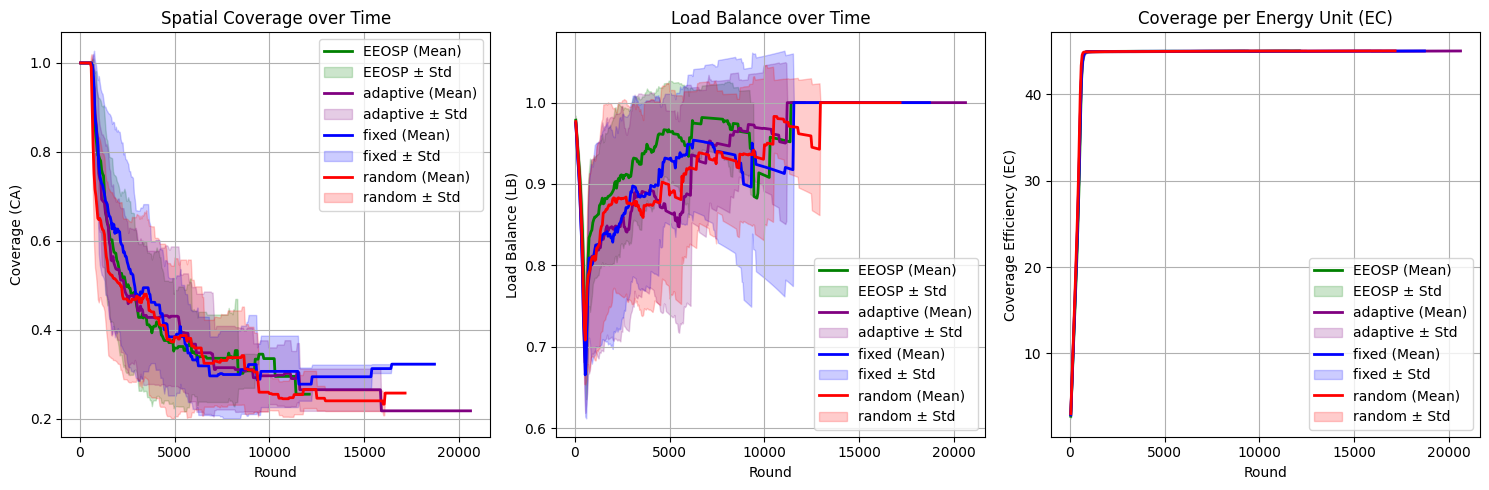

In [10]:
plt.figure(figsize=(15, 5))

# CA
plt.subplot(1, 3, 1)
plot_time_series(plot_eeosp, 'CA', "EEOSP", color='green')
plot_time_series(plot_adaptive, 'CA', "adaptive", color='purple')
plot_time_series(plot_fixed, 'CA', "fixed", color='blue')
plot_time_series(plot_random, 'CA', "random", color='red')
plt.xlabel('Round')
plt.ylabel('Coverage (CA)')
plt.title('Spatial Coverage over Time')
plt.grid(True)
plt.legend()

# LB
plt.subplot(1, 3, 2)
plot_time_series(plot_eeosp, 'LB', "EEOSP", color='green')
plot_time_series(plot_adaptive, 'LB', "adaptive", color='purple')
plot_time_series(plot_fixed, 'LB', "fixed", color='blue')
plot_time_series(plot_random, 'LB', "random", color='red')
plt.xlabel('Round')
plt.ylabel('Load Balance (LB)')
plt.title('Load Balance over Time')
plt.grid(True)
plt.legend()

# CE
plt.subplot(1, 3, 3)
plot_time_series(plot_eeosp, 'EC', "EEOSP", color='green')
plot_time_series(plot_adaptive, 'EC', "adaptive", color='purple')
plot_time_series(plot_fixed, 'EC', "fixed", color='blue')
plot_time_series(plot_random, 'EC', "random", color='red')
plt.xlabel('Round')
plt.ylabel('Coverage Efficiency (EC)')
plt.title('Coverage per Energy Unit (EC)')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.savefig('metrics_over_time.png', dpi=300, bbox_inches='tight')
plt.show()

## Different clustering methods

In [11]:
# Run both methods
OGSA_lifetimes, plot_OGSA = run_multiple_simulations(area_size=(
    100, 100), n_nodes=100, sink_mode="eeosp", routing_mode="multi-hop", mode="random", n_runs=30, CHS="optimizer")
adaptive_lifetimes, plot_adaptive = run_multiple_simulations(area_size=(
    100, 100), n_nodes=100, sink_mode="eeosp", routing_mode="multi-hop", mode="random", n_runs=30, CHS="adaptive")
random_lifetimes, plot_random = run_multiple_simulations(area_size=(
    100, 100), n_nodes=100, sink_mode="eeosp", routing_mode="multi-hop", mode="random", n_runs=30, CHS="random")


print(
    f"Mean DRL FND: {OGSA_lifetimes[0].mean():.2f} ± {OGSA_lifetimes[0].std():.2f}")
print(
    f"Mean OGSA HND: {OGSA_lifetimes[1].mean():.2f} ± {OGSA_lifetimes[1].std():.2f}")
print(
    f"Mean OGSA LND: {OGSA_lifetimes[2].mean():.2f} ± {OGSA_lifetimes[2].std():.2f}")
print(
    f"Mean OGSA PDR: {OGSA_lifetimes[3].mean():.2f} ± {OGSA_lifetimes[3].std():.2f}")
print(
    f"Mean OGSA TotalGenerated: {OGSA_lifetimes[4].mean():.2f} ± {OGSA_lifetimes[4].std():.2f}")
print(
    f"Mean OGSA TotalDelivered: {OGSA_lifetimes[5].mean():.2f} ± {OGSA_lifetimes[5].std():.2f}")
print(
    f"Mean OGSA Avg_E2E_Delay_Rounds: {OGSA_lifetimes[6].mean():.2f} ± {OGSA_lifetimes[6].std():.2f}")
print(
    f"Mean OGSA Avg_E2E_Delay_Sec: {OGSA_lifetimes[7].mean():.2f} ± {OGSA_lifetimes[7].std():.2f}")


print("\n\n\n")
print(
    f"Mean adaptive FND: {adaptive_lifetimes[0].mean():.2f} ± {adaptive_lifetimes[0].std():.2f}")
print(
    f"Mean adaptive HND: {adaptive_lifetimes[1].mean():.2f} ± {adaptive_lifetimes[1].std():.2f}")
print(
    f"Mean adaptive LND: {adaptive_lifetimes[2].mean():.2f} ± {adaptive_lifetimes[2].std():.2f}")
print(
    f"Mean adaptive PDR: {adaptive_lifetimes[3].mean():.2f} ± {adaptive_lifetimes[3].std():.2f}")
print(
    f"Mean adaptive TotalGenerated: {adaptive_lifetimes[4].mean():.2f} ± {adaptive_lifetimes[4].std():.2f}")
print(
    f"Mean adaptive TotalDelivered: {adaptive_lifetimes[5].mean():.2f} ± {adaptive_lifetimes[5].std():.2f}")
print(
    f"Mean adaptive Avg_E2E_Delay_Rounds: {adaptive_lifetimes[6].mean():.2f} ± {adaptive_lifetimes[6].std():.2f}")
print(
    f"Mean adaptive Avg_E2E_Delay_Sec: {adaptive_lifetimes[7].mean():.2f} ± {adaptive_lifetimes[7].std():.2f}")


print("\n\n\n")
print(
    f"Mean random FND: {random_lifetimes[0].mean():.2f} ± {random_lifetimes[0].std():.2f}")
print(
    f"Mean random HND: {random_lifetimes[1].mean():.2f} ± {random_lifetimes[1].std():.2f}")
print(
    f"Mean random LND: {random_lifetimes[2].mean():.2f} ± {random_lifetimes[2].std():.2f}")
print(
    f"Mean random PDR: {random_lifetimes[3].mean():.2f} ± {random_lifetimes[3].std():.2f}")
print(
    f"Mean random TotalGenerated: {random_lifetimes[4].mean():.2f} ± {random_lifetimes[4].std():.2f}")
print(
    f"Mean random TotalDelivered: {random_lifetimes[5].mean():.2f} ± {random_lifetimes[5].std():.2f}")
print(
    f"Mean random Avg_E2E_Delay_Rounds: {random_lifetimes[6].mean():.2f} ± {random_lifetimes[6].std():.2f}")
print(
    f"Mean random Avg_E2E_Delay_Sec: {random_lifetimes[7].mean():.2f} ± {random_lifetimes[7].std():.2f}")

[Info] Sink speed: 25.0 m/round = 0.50 m/s
[Info] Sink speed: 25.0 m/round = 0.50 m/s
[Info] Sink speed: 25.0 m/round = 0.50 m/s
[Info] Sink speed: 25.0 m/round = 0.50 m/s
[Info] Sink speed: 25.0 m/round = 0.50 m/s
[Info] Sink speed: 25.0 m/round = 0.50 m/s
[Info] Sink speed: 25.0 m/round = 0.50 m/s
[Info] Sink speed: 25.0 m/round = 0.50 m/s
[Info] Sink speed: 25.0 m/round = 0.50 m/s
[Info] Sink speed: 25.0 m/round = 0.50 m/s
[Info] Sink speed: 25.0 m/round = 0.50 m/s
[Info] Sink speed: 25.0 m/round = 0.50 m/s
[Info] Sink speed: 25.0 m/round = 0.50 m/s
[Info] Sink speed: 25.0 m/round = 0.50 m/s
[Info] Sink speed: 25.0 m/round = 0.50 m/s
[Info] Sink speed: 25.0 m/round = 0.50 m/s
[Info] Sink speed: 25.0 m/round = 0.50 m/s
[Info] Sink speed: 25.0 m/round = 0.50 m/s
[Info] Sink speed: 25.0 m/round = 0.50 m/s
[Info] Sink speed: 25.0 m/round = 0.50 m/s
[Info] Sink speed: 25.0 m/round = 0.50 m/s
[Info] Sink speed: 25.0 m/round = 0.50 m/s
[Info] Sink speed: 25.0 m/round = 0.50 m/s
[Info] Sink

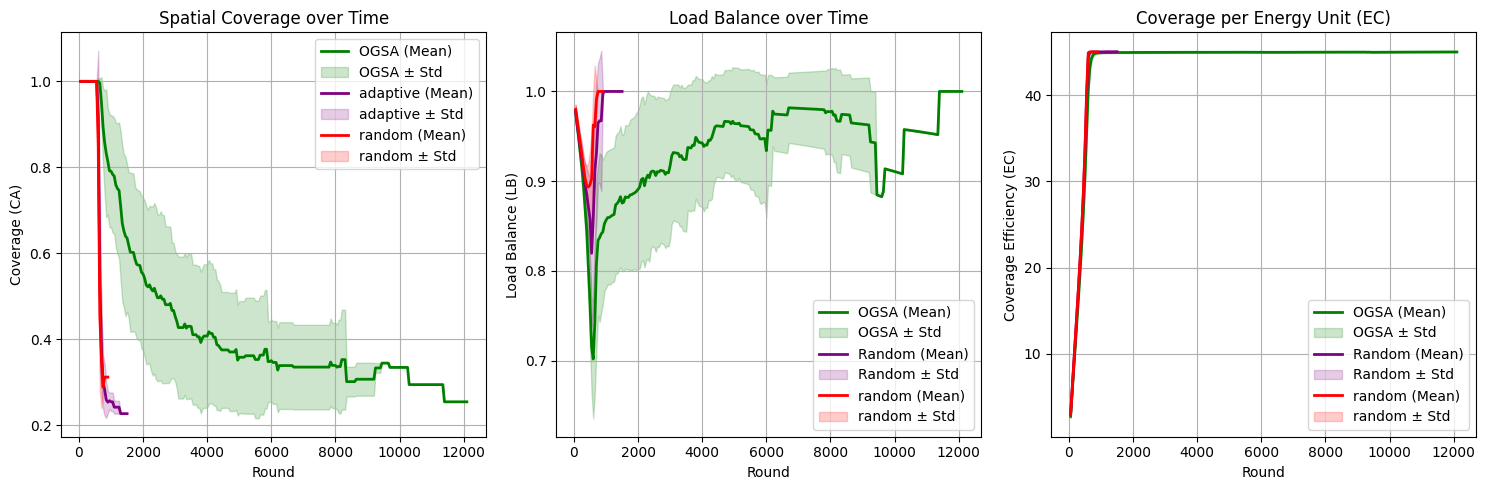

In [12]:
plt.figure(figsize=(15, 5))

# CA
plt.subplot(1, 3, 1)
plot_time_series(plot_OGSA, 'CA', "OGSA", color='green')
plot_time_series(plot_adaptive, 'CA', "adaptive", color='purple')
plot_time_series(plot_random, 'CA', "random", color='red')
plt.xlabel('Round')
plt.ylabel('Coverage (CA)')
plt.title('Spatial Coverage over Time')
plt.grid(True)
plt.legend()

# LB
plt.subplot(1, 3, 2)
plot_time_series(plot_OGSA, 'LB', "OGSA", color='green')
plot_time_series(plot_adaptive, 'LB', "Random", color='purple')
plot_time_series(plot_random, 'LB', "random", color='red')
plt.xlabel('Round')
plt.ylabel('Load Balance (LB)')
plt.title('Load Balance over Time')
plt.grid(True)
plt.legend()

# CE
plt.subplot(1, 3, 3)
plot_time_series(plot_OGSA, 'EC', "OGSA", color='green')
plot_time_series(plot_adaptive, 'EC', "Random", color='purple')
plot_time_series(plot_random, 'EC', "random", color='red')
plt.xlabel('Round')
plt.ylabel('Coverage Efficiency (EC)')
plt.title('Coverage per Energy Unit (EC)')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.savefig('metrics_over_time.png', dpi=300, bbox_inches='tight')
plt.show()